In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency

## Build a general graph with the resulting relationships

In [2]:
all_nmd_escape_final = pd.read_csv("data/2A-i_all_nmd_escape_final_wo_in_clinvar.csv")
all_nmd_undergo_final = pd.read_csv("data/2A-i_all_nmd_undergo_final_wo_in_clinvar.csv")

In [3]:
clinvar_nmd_escape_final = pd.read_csv("data/2A-i_clinvar_nmd_escape_final.csv")
clinvar_nmd_undergo_final = pd.read_csv("data/2A-i_clinvar_nmd_undergo_final.csv")

In [4]:
all_nmd_escape_final.shape

(154, 37)

In [5]:
all_nmd_escape_final

,CHROM,POS,ID,REF,ALT,AC,Consequence,IMPACT,SYMBOL,Gene,...,LoF_info,LOEUF,pext,NMD_escape,Context,Codon_position,Initial_Codon,Stop_Codon,Codon_change,Significance
0,chr5,112839436,rs1765536013,C,A,1.0,stop_gained,HIGH,APC,ENSG00000134982,...,PERCENTILE:0.450304735114862,0.161,0.904855,YES,TATCATCTTTGTCATCAGCTGAAGA,2,TCA,TAA,"('TCA', 'TAA')",pathogenic
1,chr6,7584770,NaN,G,A,1.0,stop_gained,HIGH,DSP,ENSG00000096696,...,PERCENTILE:0.871402042711235,0.260,0.999478,YES,AGGAATGTGAATGGGAAGAAATAAC,2,TGG,TAG,"('TGG', 'TAG')",pathogenic
2,chr6,7583378,NaN,T,G,1.0,stop_gained,HIGH,DSP,ENSG00000096696,...,PERCENTILE:0.709842154131848,0.260,0.999478,YES,AGAGAAAGAAATTAATCAGCCCAGA,2,TTA,TGA,"('TTA', 'TGA')",pathogenic
3,chr6,7582693,rs2113697854,G,T,1.0,stop_gained,HIGH,DSP,ENSG00000096696,...,PERCENTILE:0.630338904363974,0.260,0.999478,YES,CAGGTGGTACAGGAAAGAGAGAGCC,1,GAA,TAA,"('GAA', 'TAA')",pathogenic
4,chr6,7583287,NaN,C,T,1.0,stop_gained,HIGH,DSP,ENSG00000096696,...,PERCENTILE:0.699280408542247,0.260,0.999478,YES,GCTTCTGAAATCCAGCCATTCCTTC,1,CAG,TAG,"('CAG', 'TAG')",pathogenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,chr8,115414055,rs759477744,G,A,4.0,stop_gained,HIGH,TRPS1,ENSG00000104447,...,PERCENTILE:0.991763191763192,0.111,0.870956,YES,AGGAACAATGCACAAGTGGAAAAAA,1,CAA,TAA,"('CAA', 'TAA')",benign
150,chr7,35204522,rs113335362,G,C,3.0,stop_gained,HIGH,TBX20,ENSG00000164532,...,PERCENTILE:0.707589285714286,0.315,1.000000,YES,CATCCGTACCTACGGAGGAGAAGAA,3,TAC,TAG,"('TAC', 'TAG')",benign
151,chr7,41965049,NaN,G,A,2.0,stop_gained,HIGH,GLI3,ENSG00000106571,...,PERCENTILE:0.848408180476492,0.195,0.898291,YES,GGCCGCCCCGGTCAGCAGATGCTTG,1,CAG,TAG,"('CAG', 'TAG')",benign
152,chr17,72124351,rs2143258813,G,A,2.0,stop_gained,HIGH,SOX9,ENSG00000125398,...,PERCENTILE:0.976470588235294,0.168,1.000000,YES,CCCCCAGCACTGGGAACAACCCGTC,3,TGG,TGA,"('TGG', 'TGA')",benign


In [6]:
clinvar_nmd_escape_final.shape

(77, 32)

In [7]:
all_nmd_undergo_final.shape

(1064, 37)

In [8]:
clinvar_nmd_undergo_final.shape

(532, 32)

### 2-Ai. Also, it would be nice to create an additional plot in which we add the fifth variant group - known ClinVar pathogenic variants. For this analysis only, we will need to alter the downsampling of variants so that we sample equal number of variants from each gene in all datasets (i.e., ClinVar pat, singleton vars, gnomAD “ben”)

#### Для датафрейма Escape

In [9]:
pat_escape_variants = all_nmd_escape_final.loc[all_nmd_escape_final['Significance'] == 'pathogenic']
ben_escape_variants = all_nmd_escape_final.loc[all_nmd_escape_final['Significance'] == 'benign']

pat_estop_codon_percent = pat_escape_variants['Stop_Codon'].value_counts(normalize=True) * 100
ben_estop_codon_percent = ben_escape_variants['Stop_Codon'].value_counts(normalize=True) * 100

stop_codon_df_escape = pd.DataFrame({
    'Singleton_Escape': pat_estop_codon_percent,
    'Benign_Escape': ben_estop_codon_percent
}).reset_index().rename(columns={'index': 'Stop_Codon'})

In [10]:
stop_codon_df_escape

,Stop_Codon,Singleton_Escape,Benign_Escape
0,TAA,28.571429,19.480519
1,TAG,41.558442,32.467532
2,TGA,29.870130,48.051948


#### Для датафрейма Undergo

In [11]:
pat_undergo_variants = all_nmd_undergo_final.loc[all_nmd_undergo_final['Significance'] == 'pathogenic']
ben_undergo_variants = all_nmd_undergo_final.loc[all_nmd_undergo_final['Significance'] == 'benign']

pat_ustop_codon_percent = pat_undergo_variants['Stop_Codon'].value_counts(normalize=True) * 100
ben_ustop_codon_percent = ben_undergo_variants['Stop_Codon'].value_counts(normalize=True) * 100

stop_codon_df_undergo = pd.DataFrame({
    'Singleton_Undergo': pat_ustop_codon_percent,
    'Benign_Undergo': ben_ustop_codon_percent
}).reset_index().rename(columns={'index': 'Stop_Codon'})

In [12]:
stop_codon_df_undergo

,Stop_Codon,Singleton_Undergo,Benign_Undergo
0,TAA,24.436090,17.481203
1,TAG,43.233083,33.834586
2,TGA,32.330827,48.684211


#### Для датафрейма Clinvar

In [13]:
clinvar_ustop_codon_percent = clinvar_nmd_undergo_final['Stop_Codon'].value_counts(normalize=True) * 100
clinvar_estop_codon_percent = clinvar_nmd_escape_final['Stop_Codon'].value_counts(normalize=True) * 100

In [14]:
clinvar_stop_codon_df = pd.DataFrame({
    'Clinvar_Undergo': clinvar_ustop_codon_percent,
    'Clinvar_Escape': clinvar_estop_codon_percent
}).reset_index().rename(columns={'index': 'Stop_Codon'})

In [15]:
clinvar_stop_codon_df

,Stop_Codon,Clinvar_Undergo,Clinvar_Escape
0,TAA,18.233083,18.181818
1,TAG,40.037594,46.753247
2,TGA,41.729323,35.064935


#### Совмещаем все данные для построения графика

In [16]:
stop_codon_df = (
    stop_codon_df_escape
    .merge(stop_codon_df_undergo, on="Stop_Codon")
    .merge(clinvar_stop_codon_df, on="Stop_Codon")
    .set_index("Stop_Codon")
    .sort_index()
)

stop_codon_df 

,Singleton_Escape,Benign_Escape,Singleton_Undergo,Benign_Undergo,Clinvar_Undergo,Clinvar_Escape
Stop_Codon,,,,,,
TAA,28.571429,19.480519,24.436090,17.481203,18.233083,18.181818
TAG,41.558442,32.467532,43.233083,33.834586,40.037594,46.753247
TGA,29.870130,48.051948,32.330827,48.684211,41.729323,35.064935


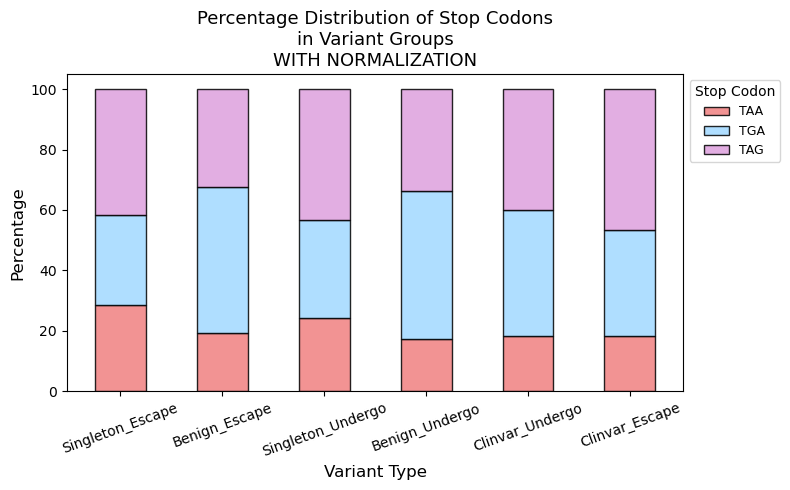

In [17]:
stop_codon_types = ['TAA', 'TGA', 'TAG']
variant_types = ['Singleton_Escape', 'Benign_Escape', 'Singleton_Undergo', 'Benign_Undergo', 'Clinvar_Undergo', 'Clinvar_Escape']

x = np.arange(len(variant_types))
colors = ['#f08080', '#a1d9ff', '#dda0dd']

fig, ax = plt.subplots(figsize=(8, 5))
bottom_values = np.zeros(len(variant_types))

for stop_codon, color in zip(stop_codon_types, colors):
    values = stop_codon_df.loc[stop_codon, variant_types].values
    ax.bar(x, values, width=0.5, label=stop_codon, color=color, bottom=bottom_values, edgecolor='black', alpha=0.85)
    bottom_values += values

ax.set_xticks(x)
ax.set_xticklabels(variant_types, rotation=20, fontsize=10)
ax.set_xlabel('Variant Type', fontsize=12)
ax.set_ylabel('Percentage', fontsize=12)
ax.set_title('Percentage Distribution of Stop Codons\nin Variant Groups\nWITH NORMALIZATION', fontsize=13)
ax.legend(title='Stop Codon', fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()